# Isolation with Migration (IM) Model

Formålet med denne notebook er at udvide two-island modellen med  split-begivenhed og asymmetrisk migration ved hjælp af Phasic's tidsinhomogene framework. I Sørensen et al. (2023) estimeres der at nord-syd splittet i bavianer skete for ca. 1–1.2 milioner år siden. 

IM-modellen tilføjer:

- En split-tid $\tau$ (ingen migration før splittet)
- Variabel populationsstørrelse over tid
- Mulighed for at fitte til SFS per epoke

Jeg bruger Phasic's step-wise tidsinhomogene framework: *distribution_context*, *update_weights*, *accumulated_occupancy* og *graph.extend*.

I denne notebook vil jeg komme ind på følgende:

1. Imports og data
2. Teori: IM-modellen som epoker
3. Byg epoch-baseret coalescent med StateIndexer
4. Tilføj migration-epoke (IM-modellen)
5. SFS under IM-modellen
6. PDF/CDF og tidsinhomogen visualisering

## 1. Imports og data

In [22]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    clear_jax_cache, clear_model_cache,
    StateIndexer, Property, PropertySet, set_log_level
) # ALWAYS import phasic first to set jax backend correctly
set_log_level('WARNING')

import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from typing import Optional, Callable
from functools import partial
from itertools import combinations, combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)

from vscodenb import set_vscode_theme
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

import matplotlib.patches as mpatches
from scipy.optimize import minimize, differential_evolution
from pathlib import Path

all_pairs = partial(combinations_with_replacement, r=2)

OUT_DIR  = Path("output")
MU       = 0.9e-8
GEN_TIME = 11
N1_REF   = 100_000

print("Imports OK")

Imports OK


In [23]:
# Indlæser data fra Notebook 03
sfs_ye_f = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_ki_f = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()
pi_df    = pd.read_csv(OUT_DIR / "pi_per_population.csv",      index_col=0)

# Henter two-island m-estimat fra Notebook 04 som startgæt
try:
    nb2 = pd.read_csv(OUT_DIR / "two_island_results.csv", index_col=0)
    m_init = float(nb2.loc["m_hat (til NB3)", "Værdi"])
    print(f"Two-island m som startgæt: {m_init:.5f}")
except Exception:
    m_init = 0.05
    print(f"Bruger standard startgæt m = {m_init}")

n_yellow = len(sfs_ye_f) + 1
n_kinda  = len(sfs_ki_f) + 1
print(f"n_yellow = {n_yellow}, n_kinda = {n_kinda}")

Two-island m som startgæt: 0.10023
n_yellow = 36, n_kinda = 30


## 2. Teori: IM-modellen som epoker

Jeg implementerer IM-modellen som to epoker.

**Parametre:**

| Parameter | Beskrivelse | *update_weights* indeks |
|-----------|-------------|-------------------------|
| $1/N_1$   | Coalescensrate, epoke 0 | 0 |
| $m$       | Migrationrate, epoke 0  | 1 |
| $1/N_A$   | Coalescensrate, epoke 1 (ancestral) | 2 |
| — | Epokeovergangsrate (intern) | 3 |

Jeg bruger *distribution_context()* til at styre overgangen ved split-tid $\tau$.

## 3. Byg epoch-baseret coalescent med StateIndexer

Jeg følger Phasic-dokumentationens *Coalescent_1param*-mønster med en *epoch*-slot i state-vektoren.

In [24]:
nr_samples = 10   # haploid sample size per population 
epochs     = [0, 1]         # to epoker: 0 = migration, 1 = ancestral
pop_sizes  = [1.0, 2.0]     # relativ Ne: [N1, NA] 

indexer = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=nr_samples)],
    slots=['epoch']
)

print(f"State-vektor længde: {indexer.state_length}")
print(f"Epoch-slot indeks:   {indexer.epoch}")

State-vektor længde: 11
Epoch-slot indeks:   10


In [25]:
def coalescent_epochs(state, epochs=None, epoch_idx=None, indexer=None):
    """
    Coalescent-callback der bruger epoch-slot til at styre epoker.

    Parametre (sættes med update_weights):
      coeff[0] = coalescensrate i epoke 0 (= 1/N1)
      coeff[1] = migrationrate i epoke 0  (= m)
      coeff[2] = coalescensrate i epoke 1 (= 1/NA)
      coeff[3] = epokeovergangsrate 
    """
    transitions = []
    epoch_idx   = int(epoch_idx)

    # Ignorer state fra andre epoker
    if state[indexer.epoch] != epoch_idx:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)

        if state.sum() <= 1:
            continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue

        new    = state.copy()
        new[i] -= 1
        new[j] -= 1
        k       = indexer.props_to_index(ton=pi.ton + pj.ton)
        new[k] += 1

        # En koefficient per epoke + en til epokeovergange
        coeff            = np.zeros(len(epochs) + 1)
        coeff[epoch_idx] = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, coeff])

    return transitions


print("coalescent_epochs callback defineret.")

coalescent_epochs callback defineret.


In [26]:
def add_epoch(graph, callback, epochs, epoch_idx, indexer):
    """
    Tilføjer en ny epoke til grafen.

    Bruger accumulated_occupancy og stop_probability til at beregne
    overgangsrater fra epoke epoch_idx-1 til epoch_idx.
    """
    epoch      = epochs[epoch_idx]
    stop_probs = np.array(graph.stop_probability(epoch))
    accum_occ  = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid='ignore'):
        epoch_trans_rates = stop_probs / accum_occ

    for i in range(1, graph.vertices_length() - 1):
        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state  = vertex.state()

        # Kun state fra foregående epoke
        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        # Opret søster-state i ny epoke
        sister_state               = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child  = graph.find_or_create_vertex(sister_state)

        coeff       = np.zeros(len(epochs) + 1)
        coeff[-1]   = epoch_trans_rates[i]     # epokeovergang
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)


print("add_epoch funktion defineret.")

add_epoch funktion defineret.


## 4. Byg IM-modellen

Jeg bygger grafen trin for trin:

1. Byg epoke 0 (migration + coalescens i begge populationer)
2. Sæt parametre med *update_weights*
3. Tilføj epoke 1 (ancestral population, kun coalescens)
4. Opdater vægte igen

In [27]:
# Initial state: alle linjer er singletons i epoke 0
ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = nr_samples

# Split-tid i coalescent-enheder
tau = 1e6 / (GEN_TIME * N1_REF)
epochs     = [0, tau]       # start-tidspunkter for epoker (coalescent-enheder)
pop_sizes  = [1.0, 2.0]     # [N1, NA] relativt til reference

print(f"Split-tid τ = {tau:.4f} (coalescent-enheder)")
print(f"             = {tau * N1_REF * GEN_TIME / 1e6:.2f} millioner år")

# Byg grafen 
graph_im = Graph(
    coalescent_epochs,
    ipv=ipv,
    epochs=epochs,
    epoch_idx=0,
    indexer=indexer,
)

# Parametre: [1/N1 (epoke 0), m (epoke 0), 1/NA (epoke 1), epokeovergang]
graph_im.update_weights([1/pop_sizes[0], 1/pop_sizes[1]] + [1])

# Tilføj epoke 1 (ancestral)
add_epoch(graph_im, coalescent_epochs, epochs, 1, indexer)
graph_im.update_weights([1/pop_sizes[0], 1/pop_sizes[1]] + [1])

print(f"\nAntal state: {graph_im.vertices_length()}")
print(f"Moments (5):     {graph_im.moments(5)}")

Split-tid τ = 0.9091 (coalescent-enheder)
             = 1.00 millioner år

Antal state: 85
Moments (5):     [2.730111468006326, 11.744825916765738, 72.0156676445117, 580.4234646914543, 5819.476842151254]


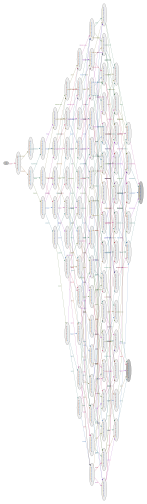

In [34]:
graph = Graph(graph_im,
              N=1, R=1,
              indexer=indexer) # passing indexer as argument
graph.plot(max_nodes=200)   

## 5. SFS under IM-modellen

Jeg beregner den forventede SFS via reward-transformation.

State matrix shape: (85, 11)
Rewards shape:      (85, 10)  (vertices × SFS-bins)


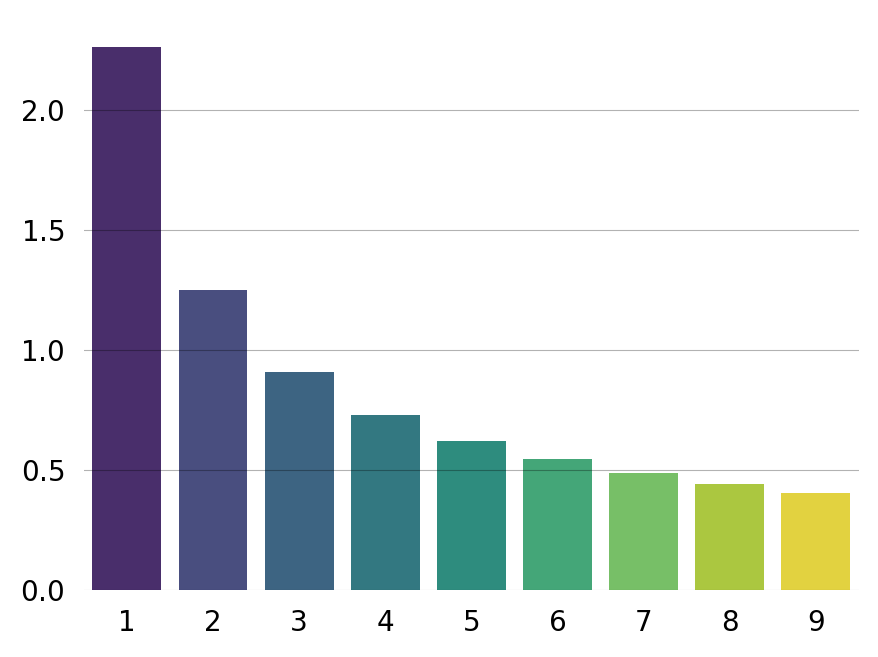

In [ ]:
# Reward-matrix: en kolonne per SFS-bin (singletons, doubletons, ...)
# Fjern epoch-label-kolonnen fra states
state_mat = graph_im.states()
rewards   = state_mat[:, :-1]   # fjern sidste kolonne (epoch)

print(f"State matrix shape: {state_mat.shape}")
print(f"Rewards shape:      {rewards.shape}  (vertices × SFS-bins)")

# Beregn forventet SFS
x   = np.arange(1, nr_samples)
sfs = np.zeros(nr_samples - 1)

for i in range(nr_samples - 1):
    reward_vec         = rewards[:, i]
    transformed_graph  = graph_im.reward_transform(reward_vec)
    sfs[i]             = transformed_graph.moments(1)[0]

sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette='iridis', legend=False);

## 6. PDF/CDF og tidsinhomogen visualisering

Jeg bruger *distribution_context()* til at steppe igennem den tidsinhomogene fordeling. Phasic's framework til bottlenecks og epoker.

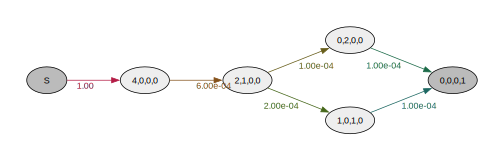

In [41]:
# Genbyg en simpel enkelt-population graf til CDF-demonstration
# (viser bottleneck-approachen fra dokumentationen)
nr_s = 4

@with_ipv([nr_s] + [0] * (nr_s - 1))
def coal_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_demo = Graph(coal_1param)
N = 10000
graph_demo.update_weights([1/N])

graph_demo.plot()


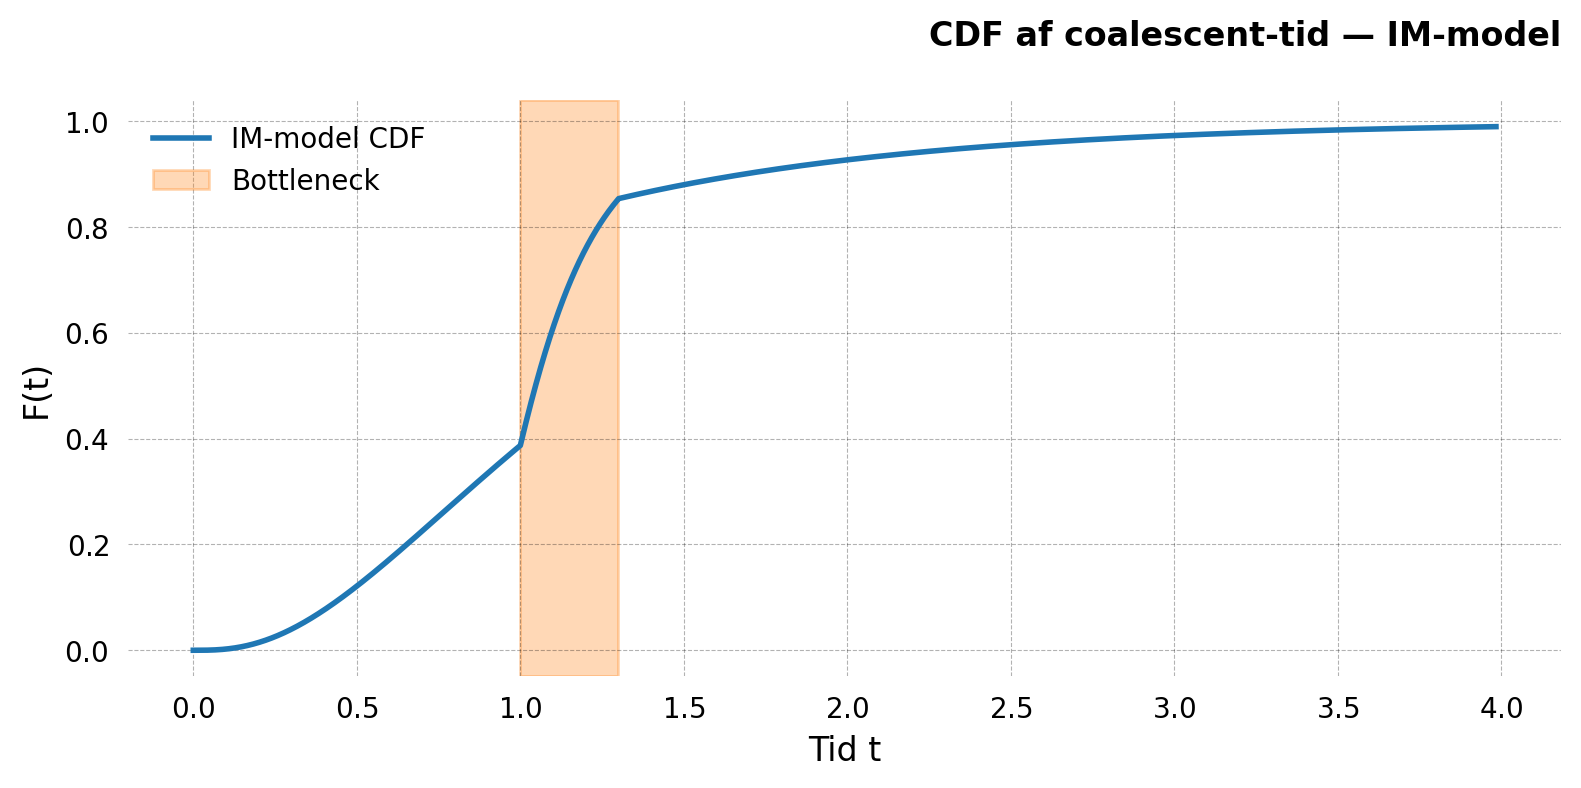

In [42]:
# IM-scenarie
graph_demo = Graph(coal_1param)

N = 1
N_bottle, t_start, t_end = 0.2, 1, 1.3

# Parameterændringer: 
param_changes = [         
                 (t_start, [1/N_bottle]), 
                 (t_end,   [1/N]) 
                 ]

cdf_cutoff = 0.99
cdf = []
times    = []
ctx = graph_demo.distribution_context()
graph_demo.update_weights([1/N])

for change_time, new_params in param_changes:
    while ctx.time() < change_time:
        cdf.append(ctx.cdf())
        times.append(ctx.time())
        ctx.step()
        if ctx.cdf() >= cdf_cutoff:
            break
    graph_demo.update_weights(new_params)
while ctx.cdf() < cdf_cutoff:
    cdf.append(ctx.cdf())
    times.append(ctx.time())
    ctx.step()


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, cdf, color='C0', lw=2, label="IM-model CDF")
ax.axvspan(xmin=t_start, xmax=t_end, alpha = 0.3, color='C1', label='Bottleneck')
ax.set_xlabel("Tid t", fontsize=12)
ax.set_ylabel("F(t)", fontsize=12)
ax.set_title("CDF af coalescent-tid — IM-model\n",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "im_cdf_context.png", dpi=150, bbox_inches="tight")
plt.show()